In [91]:
import json 
from collections import Counter
import seaborn as sns
import pandas as pd
from pathlib import Path
import pickle
import sys
sys.path.append("..")
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
plt.tight_layout()

<Figure size 432x288 with 0 Axes>

In [76]:
mixfactor = 0.5
interpret_mode ="gcn_only"
#interpret_mode ="gcn_bert"
ig_path = f"../models/gcn/{mixfactor}/ig_attrs_{interpret_mode}.json"
shap_path = f"../models/gcn/{mixfactor}/shap_values_{interpret_mode}.json"
ig_gcn_only_path = f"../models/gcn/{mixfactor}/ig_attrs_gcn_only.json"
shap_gcn_only_path = f"../models/gcn/{mixfactor}/shap_values_gcn_only.json"
ig_gcn_bert_path = f"../models/gcn/{mixfactor}/ig_attrs_gcn_bert.json"
shap_gcn_bert_path = f"../models/gcn/{mixfactor}/shap_values_gcn_bert.json"

In [82]:
ig_df = pd.read_json(ig_path).T#.explode("label")
ig_gcn_only_df = pd.read_json(ig_gcn_only_path).T#.explode("label")
ig_gcn_bert_df = pd.read_json(ig_gcn_bert_path).T#.explode("label")
shap_df = pd.read_json(shap_path).T#.explode("label")
shap_gcn_only_df = pd.read_json(shap_gcn_only_path).T#.explode("label")
shap_gcn_bert_df = pd.read_json(shap_gcn_bert_path).T#.explode("label")

In [105]:
shap_gcn_bert_df

,label,rel_doc_ids,rel_doc_labels
27456,Blutdrucksenker_beides,"[53, 27968, 27456, 634, 1392, 106, 27698, 1162...","[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27457,Blutdrucksenker_Herzschw,"[27457, 1884, 27201, 27206, 1031, 27708, 27957...","[Blutdrucksenker_Herzschw, Blutdrucksenker_Her..."
27458,Blutdrucksenker_Blutdruck,"[20, 1761, 27257, 1053, 1841, 1211, 27644, 274...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27459,Cholesterinsenker_unklar,"[267, 27216, 900, 27437, 1564, 992, 355, 466, ...","[Blutdrucksenker_unklar, Blutdrucksenker_unkla..."
27460,Blutdrucksenker_unklar,"[900, 27550, 1102, 291, 27460, 1451, 1674, 278...","[Blutdrucksenker_unklar, Blutdrucksenker_unkla..."
...,...,...,...
27991,Blutdrucksenker_Blutdruck,"[147, 27991, 27743, 2, 27830, 1881, 27317, 271...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27992,Blutdrucksenker_beides,"[27400, 1622, 1185, 373, 27992, 1706, 1096, 27...","[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27993,Cholesterinsenker_beides,"[27704, 27741, 27993, 1878, 27701, 1446, 1721,...","[Cholesterinsenker_beides, Cholesterinsenker_b..."
27994,Blutdrucksenker_Blutdruck,"[27616, 27366, 493, 1548, 18, 27445, 363, 2758...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."


In [106]:
ig_gcn_only_df.explode("rel_doc_ids")#.rel_doc_ids.value_counts()[:10]

,label,rel_doc_ids,rel_doc_labels
27456,Blutdrucksenker_beides,106,"[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27456,Blutdrucksenker_beides,634,"[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27456,Blutdrucksenker_beides,27968,"[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27456,Blutdrucksenker_beides,53,"[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27456,Blutdrucksenker_beides,1392,"[Blutdrucksenker_beides, Blutdrucksenker_beide..."
...,...,...,...
27995,Blutdrucksenker_Blutdruck,1029,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27995,Blutdrucksenker_Blutdruck,27914,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27995,Blutdrucksenker_Blutdruck,27497,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27995,Blutdrucksenker_Blutdruck,27304,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."


In [84]:
ig_gcn_bert_df.explode("rel_doc_ids").rel_doc_ids.value_counts()[:10]

992      16
1451     15
900      15
27550    14
334      13
291      13
1674     13
27580    11
467      11
1628     11
Name: rel_doc_ids, dtype: int64

In [85]:
shap_gcn_only_df.explode("rel_doc_ids").rel_doc_ids.value_counts()[:10]

992      14
1674     13
900      12
27256    11
1628     11
27741    11
1271     11
1675     10
27763     9
71        9
Name: rel_doc_ids, dtype: int64

In [86]:
shap_gcn_bert_df.explode("rel_doc_ids").rel_doc_ids.value_counts()[:10]

992      16
27741    14
1674     13
334      11
27827    10
27691     9
1271      9
71        9
1860      9
1628      9
Name: rel_doc_ids, dtype: int64

In [87]:
ig_gcn_only_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Blutdrucksenker_Blutdruck             1679
Blutdrucksenker_beides                1458
Cholesterinsenker_beides               720
Blutdrucksenker_Herzschw               425
DM_Insulin und Tabletten               320
DM_nur Tabletten                       262
Cholesterinsenker_KHK                  219
Blutdrucksenker_unklar                 173
DM_nur Insulin                          69
Cholesterinsenker_unklar                48
Cholesterinsenker_Hypercholesterin      22
Blutdrucksenker_Hypercholesterin         5
Name: rel_doc_labels, dtype: int64

In [88]:
ig_gcn_bert_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Blutdrucksenker_Blutdruck             1848
Blutdrucksenker_beides                1528
Cholesterinsenker_beides               624
Blutdrucksenker_Herzschw               401
Blutdrucksenker_unklar                 305
Cholesterinsenker_KHK                  169
DM_nur Tabletten                       141
Cholesterinsenker_unklar               134
DM_Insulin und Tabletten               129
DM_nur Insulin                          72
Cholesterinsenker_Hypercholesterin      43
Blutdrucksenker_Hypercholesterin         6
Name: rel_doc_labels, dtype: int64

In [90]:
shap_gcn_only_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Blutdrucksenker_Blutdruck             1766
Blutdrucksenker_beides                1502
Cholesterinsenker_beides               726
Blutdrucksenker_Herzschw               390
Blutdrucksenker_unklar                 234
Cholesterinsenker_KHK                  187
DM_Insulin und Tabletten               178
DM_nur Tabletten                       173
Cholesterinsenker_unklar               118
DM_nur Insulin                          75
Cholesterinsenker_Hypercholesterin      40
Blutdrucksenker_Hypercholesterin        11
Name: rel_doc_labels, dtype: int64

In [89]:
shap_gcn_bert_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Blutdrucksenker_Blutdruck             1768
Blutdrucksenker_beides                1507
Cholesterinsenker_beides               713
Blutdrucksenker_Herzschw               394
Blutdrucksenker_unklar                 223
Cholesterinsenker_KHK                  192
DM_Insulin und Tabletten               183
DM_nur Tabletten                       173
Cholesterinsenker_unklar               121
DM_nur Insulin                          79
Cholesterinsenker_Hypercholesterin      38
Blutdrucksenker_Hypercholesterin         9
Name: rel_doc_labels, dtype: int64

In [107]:
ig_df

,label,rel_doc_ids,rel_doc_labels
27456,Blutdrucksenker_beides,"[106, 634, 27968, 53, 1392, 27456, 27649, 1162...","[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27457,Blutdrucksenker_Herzschw,"[1783, 27708, 27457, 1884, 27957, 27206, 27201...","[Blutdrucksenker_Herzschw, Blutdrucksenker_Her..."
27458,Blutdrucksenker_Blutdruck,"[1211, 27458, 20, 1761, 1053, 27644, 1592, 184...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27459,Cholesterinsenker_unklar,"[466, 27437, 1207, 492, 618, 1287, 27646, 2743...","[DM_Insulin und Tabletten, DM_Insulin und Tabl..."
27460,Blutdrucksenker_unklar,"[900, 1102, 1451, 27460, 1514, 27990, 27550, 1...","[Blutdrucksenker_unklar, Blutdrucksenker_unkla..."
...,...,...,...
27991,Blutdrucksenker_Blutdruck,"[147, 27743, 2, 271, 27991, 27317, 1881, 27830...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."
27992,Blutdrucksenker_beides,"[373, 1185, 27992, 27400, 1622, 1706, 27752, 1...","[Blutdrucksenker_beides, Blutdrucksenker_beide..."
27993,Cholesterinsenker_beides,"[27587, 27701, 27993, 1835, 27704, 27741, 1446...","[Cholesterinsenker_beides, Cholesterinsenker_b..."
27994,Blutdrucksenker_Blutdruck,"[27616, 27994, 1548, 18, 493, 29, 27445, 27366...","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl..."


array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}, xlabel='rel_doc_labels'>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}, xlabel='rel_doc_labels'>,
 

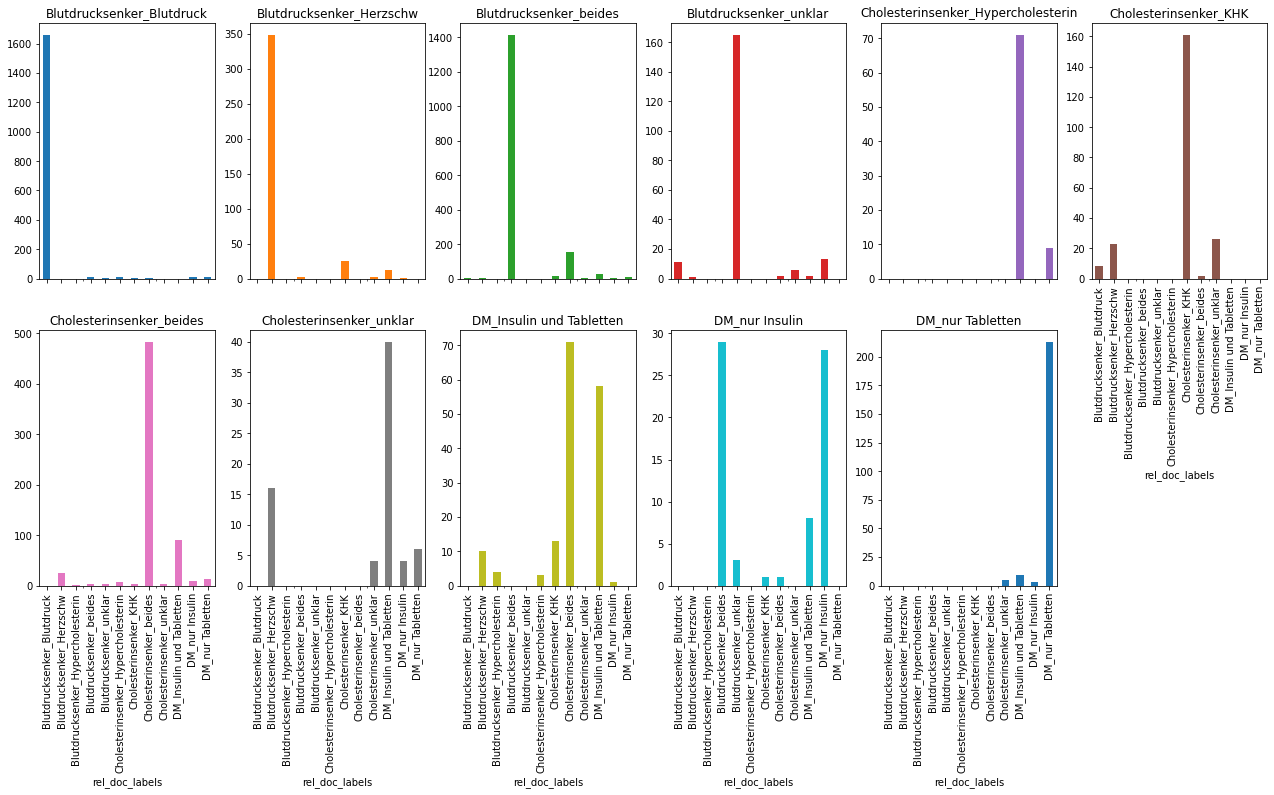

In [39]:
ig_rel_doc_labels_vc = ig_df.explode("rel_doc_labels").groupby("label")["rel_doc_labels"].value_counts()
ig_rel_doc_labels_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)

array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}, xlabel='rel_doc_labels'>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}, xlabel='rel_doc_labels'>,
 

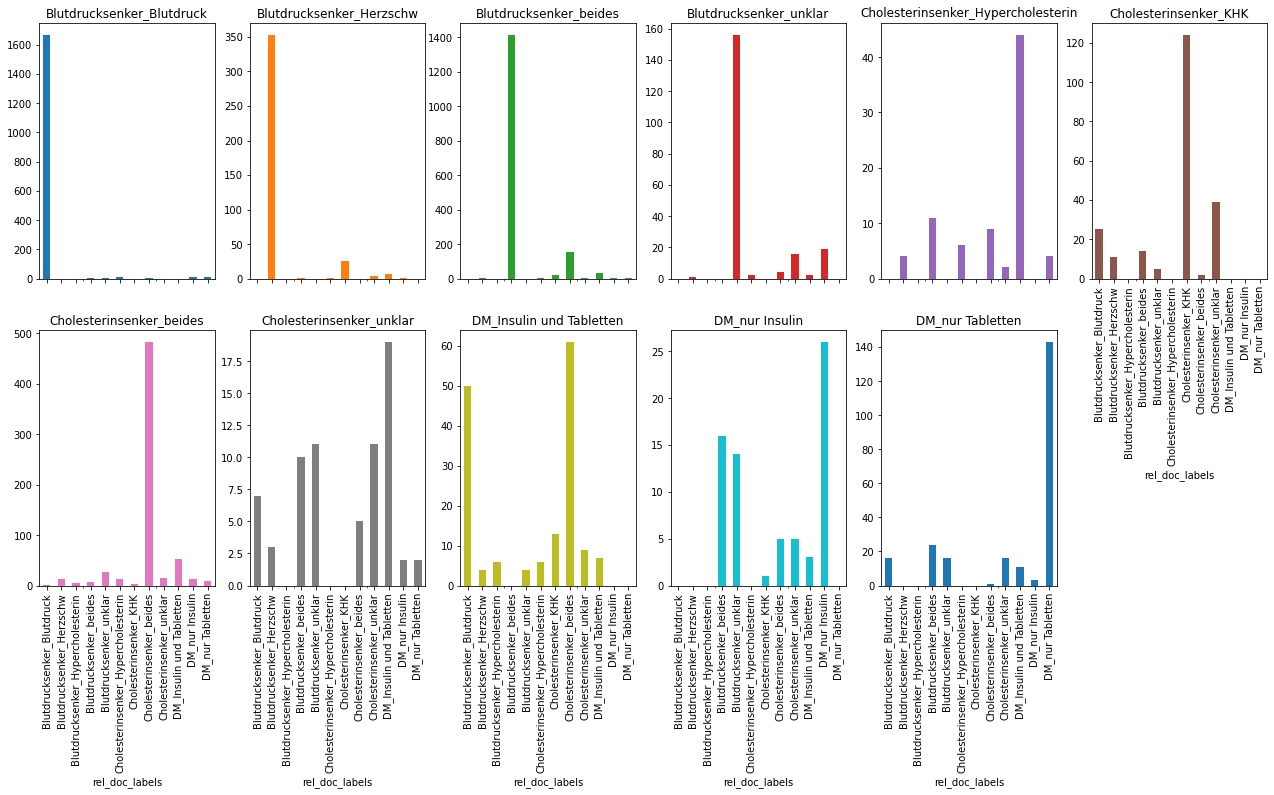

In [36]:
shap_rel_doc_labels_vc = shap_df.explode("rel_doc_labels").groupby("label")["rel_doc_labels"].value_counts()
shap_rel_doc_labels_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)

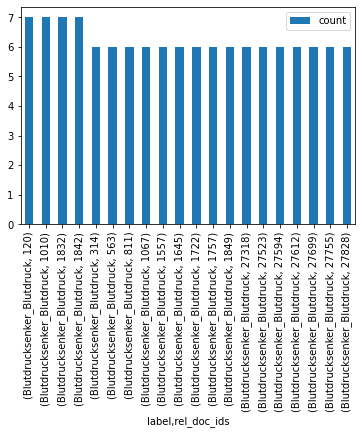

In [75]:
g = ig_df.explode("rel_doc_ids").groupby("label")["rel_doc_ids"].value_counts().to_frame().rename({'rel_doc_ids': 'count',}, axis=1).groupby(level=0)

for idx, data in g:
    data[:20].plot(kind='bar')
    break

array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}, xlabel='rel_doc_ids'>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}, xlabel='rel_doc_ids'>,
        <AxesSubplot:xlabel='rel_d

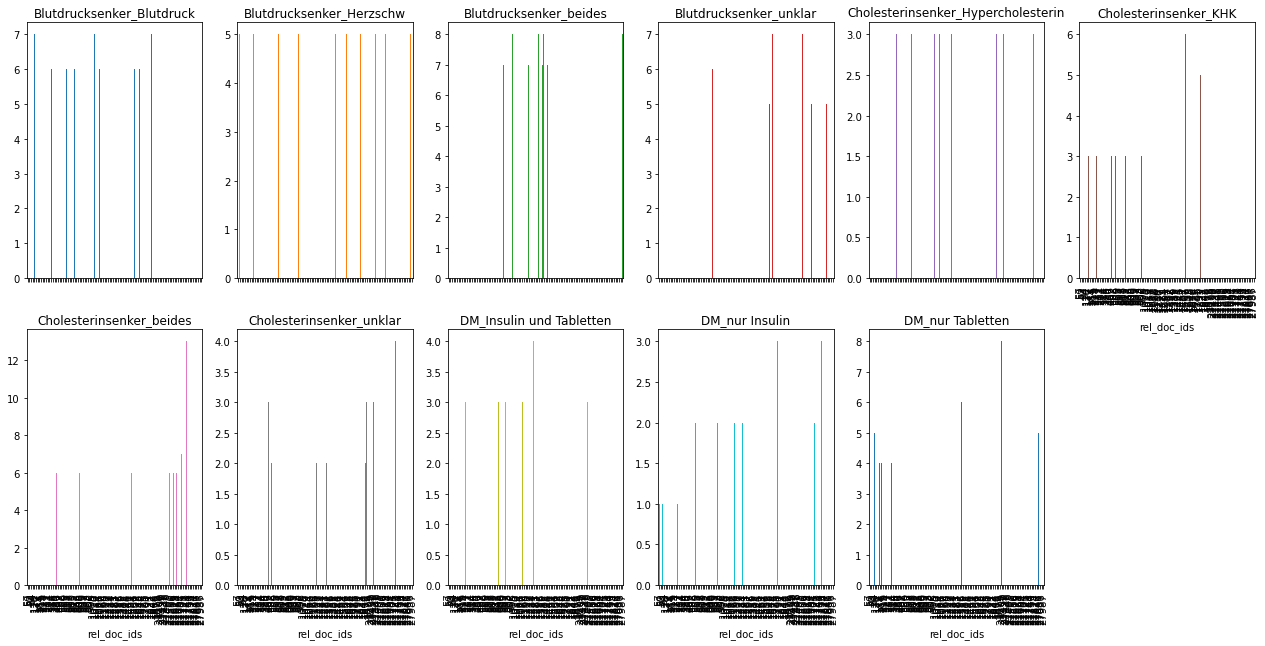

In [53]:
rel_doc_ids_vc = ig_df.explode("rel_doc_ids").groupby("label")["rel_doc_ids"].value_counts()
rel_doc_ids_vc.unstack(0).T.apply(pd.Series.nlargest, axis=1, n=10).T.plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xticks=None)#xlabel=None, xticks=None, use_index=False)
